<a href="https://colab.research.google.com/github/Raju-24-25/Deep-Learning-Handsons/blob/main/NN_Frameworks_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### `Problem Statement` :
This assignment challenges students to construct and train a neural network to
accurately classify handwritten digits from the MNIST dataset. The goal is to
navigate through the preprocessing of image data, select an appropriate neural
network architecture, and apply optimization techniques to achieve high
classification accuracy.

`Introduction` :
The MNIST dataset is a large database of handwritten digits commonly used for
training various image processing systems. The dataset contains 60,000 training
images and 10,000 testing images, each of which is a 28x28 pixel grayscale
image. The goal is to build a neural network model that can accurately classify
these images into one of the ten digit classes (0 through 9).

`Objectives` :
Data Preprocessing: Prepare the MNIST dataset for training and testing the
neural network model. This includes normalization of image pixel values and
converting the output labels to a one-hot encoded format.

`Model Development` : Create a neural network model capable of classifying
28x28 pixel grayscale images of handwritten digits. The model should have an
input layer, one or more hidden layers, and an output layer.
Training: Train the neural network model using the preprocessed training data.
Utilize categorical cross-entropy as the loss function, stochastic gradient descent as the optimizer, and track accuracy as a performance metric.

`Evaluation` : Evaluate the performance of the trained model using the testing
dataset, ensuring that the model generalizes well to unseen data.

`Prediction` : Implement functionality to make predictions on single images or
batches of images, returning the digit class with the highest probability.
Analysis: Analyze the results, understand the model's performance, and explore
ways to improve it if necessary.

### `Challenges and Considerations` :

`Class Imbalance` : Ensure that the dataset does not have a significant class
imbalance that could negatively affect the model’s performance. If imbalance is
present, strategies to mitigate its effects should be considered.
Model Complexity: Choose an appropriate model complexity that is capable of
learning from the data without overfitting. This may involve experimenting with
different numbers of layers and units, as well as regularization techniques.
Activation Functions: Use appropriate activation functions in the hidden layers
(ReLU is commonly used for image data) and softmax activation in the output
layer to convert logits to probabilities.

`Evaluation Metrics` : Focus on accuracy as the primary evaluation metric, but
also be open to exploring other metrics that could provide additional insights into the model’s performance.

`Hyperparameter Tuning` : Experiment with different hyperparameters such as
learning rate, batch size, and number of epochs to optimize the model’s
performance.

`Predictions and Interpretability` : Provide clear and interpretable predictions,
ensuring that the output probabilities are well-calibrated and meaningful.

### `Step 1` : Import Libraries

In [11]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

### `Step 2` : Load MNIST Dataset

In [12]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


### `Step 3` : Data Preprocessing

In [13]:
# i. Normalize Data (0 → 255 → 0 → 1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# ii. Flatten Images (28×28 → 784)
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

# iii. One-Hot Encode Labels
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

### `Step 4` : Build Neural Network Model

In [14]:
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

### `Step 5` : Compile Model

In [15]:
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### `Step 6` : Train Model

In [16]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7980 - loss: 0.7436 - val_accuracy: 0.9063 - val_loss: 0.3398
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9070 - loss: 0.3247 - val_accuracy: 0.9208 - val_loss: 0.2755
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9229 - loss: 0.2696 - val_accuracy: 0.9343 - val_loss: 0.2361
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9321 - loss: 0.2356 - val_accuracy: 0.9394 - val_loss: 0.2141
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9395 - loss: 0.2098 - val_accuracy: 0.9431 - val_loss: 0.1980
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9458 - loss: 0.1893 - val_accuracy: 0.9471 - val_loss: 0.1846
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9509 - loss: 0.1722 - val_accuracy: 0.9532 - val_loss: 0.1659
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9549 - loss: 0.1576 - 

### `Step 7` : Evaluate Model

In [17]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9596 - loss: 0.1384
Test Accuracy: 0.9595999717712402


### `Step 8` : Make Predictions

In [18]:
predictions = model.predict(x_test)

# Example: first image
print("Predicted:", np.argmax(predictions[0]))
print("Actual:", np.argmax(y_test[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted: 7
Actual: 7


### `Step 9` : Visualize Prediction

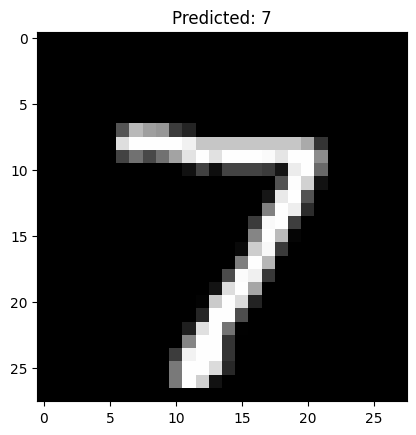

In [19]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title("Predicted: " + str(np.argmax(predictions[0])))
plt.show()